In [1]:
using Base.Threads
println( "Number of threads: ", nthreads() )

include( "../args.jl" )
include( "../model.jl" )
include( "../geom.jl" )

Number of threads: 24
Loaded network.jl class file.
Loaded model.jl class file.
Loaded geom.jl class file.


In [2]:
# System parameters.
μ = 1.0
N = defInt( 100 )
L = √(N/μ)

# Data folder name.
ξ = 0.1
case = "../data/results/case-0/"
folder = case*"N-$(N)/mu-$(round( μ, digits=3 ))_xi-$(round( ξ, digits=5 ))/"

"../data/results/case-0/N-100/mu-1.0_xi-0.1/"

In [3]:
# Load parameters.
δt = Δt
scale = loadscale( folder*"sim-scale.json" )
params = loadparams( folder*"sim-params.json" )
nondim = Nondim( params; scale=scale )

Nondim(0.1, 0.010000000000000002, 0.010000000000000002, 0.0002, 750.0, 1.0, 0.5, 0.0, 0.5, 0.25, 5.869067175274828, 1.0, 0.7853981633974483, LogNormal{Float64}(μ=-0.11157177565710488, σ=0.47238072707743883), Truncated(Laplace{Float64}(μ=0.0, θ=0.5); lower=-3.141592653589793, upper=3.141592653589793))

In [4]:
# Import position data.
M = 100
xdatalist = [readdlm( folder*"sim/x-state_m-$(m).txt" ) for m ∈ 1:M]
ydatalist = [readdlm( folder*"sim/y-state_m-$(m).txt" ) for m ∈ 1:M]

# Import activity data.
T = 5000
adata = readdlm( folder*"activity_T-$(round( T )).txt" );
tlist = 1:size( adata )[2]  # Index time-series.

1:1001

In [5]:
# Compute pair-wise distances.
Tdist = 201
Ddata = [[pairwisedist( L, xdata[t,:], ydata[t,:] ) for t ∈ 1:Tdist]
    for (xdata, ydata) ∈ zip( xdatalist, ydatalist )]

# Build pair-wise distributions.
dlist = [d for Dlist ∈ Ddata for D ∈ Dlist for d ∈ D]

# Compute the distribution describing the spread of agents.
dmax = maximum( dlist )
Δd = 0.01;  dbins = 0:Δd:L/√2
H = fit( Histogram, dlist, dbins )
@assert dmax < L/√2 "There exists a distance greater than the boundaries allow."

# Normalize distribution for plotting.
d̂list = dbins[1:end-1] .+ Δd/2
flist = H.weights/(Δd*sum( H.weights ))
fmax = maximum( flist );

# Line describing the slope of p(d).
xlist = 0:Δd:L/2
ylist = (2π/L^2).*xlist

0.0:0.0006283185307179587:0.31415926535897937

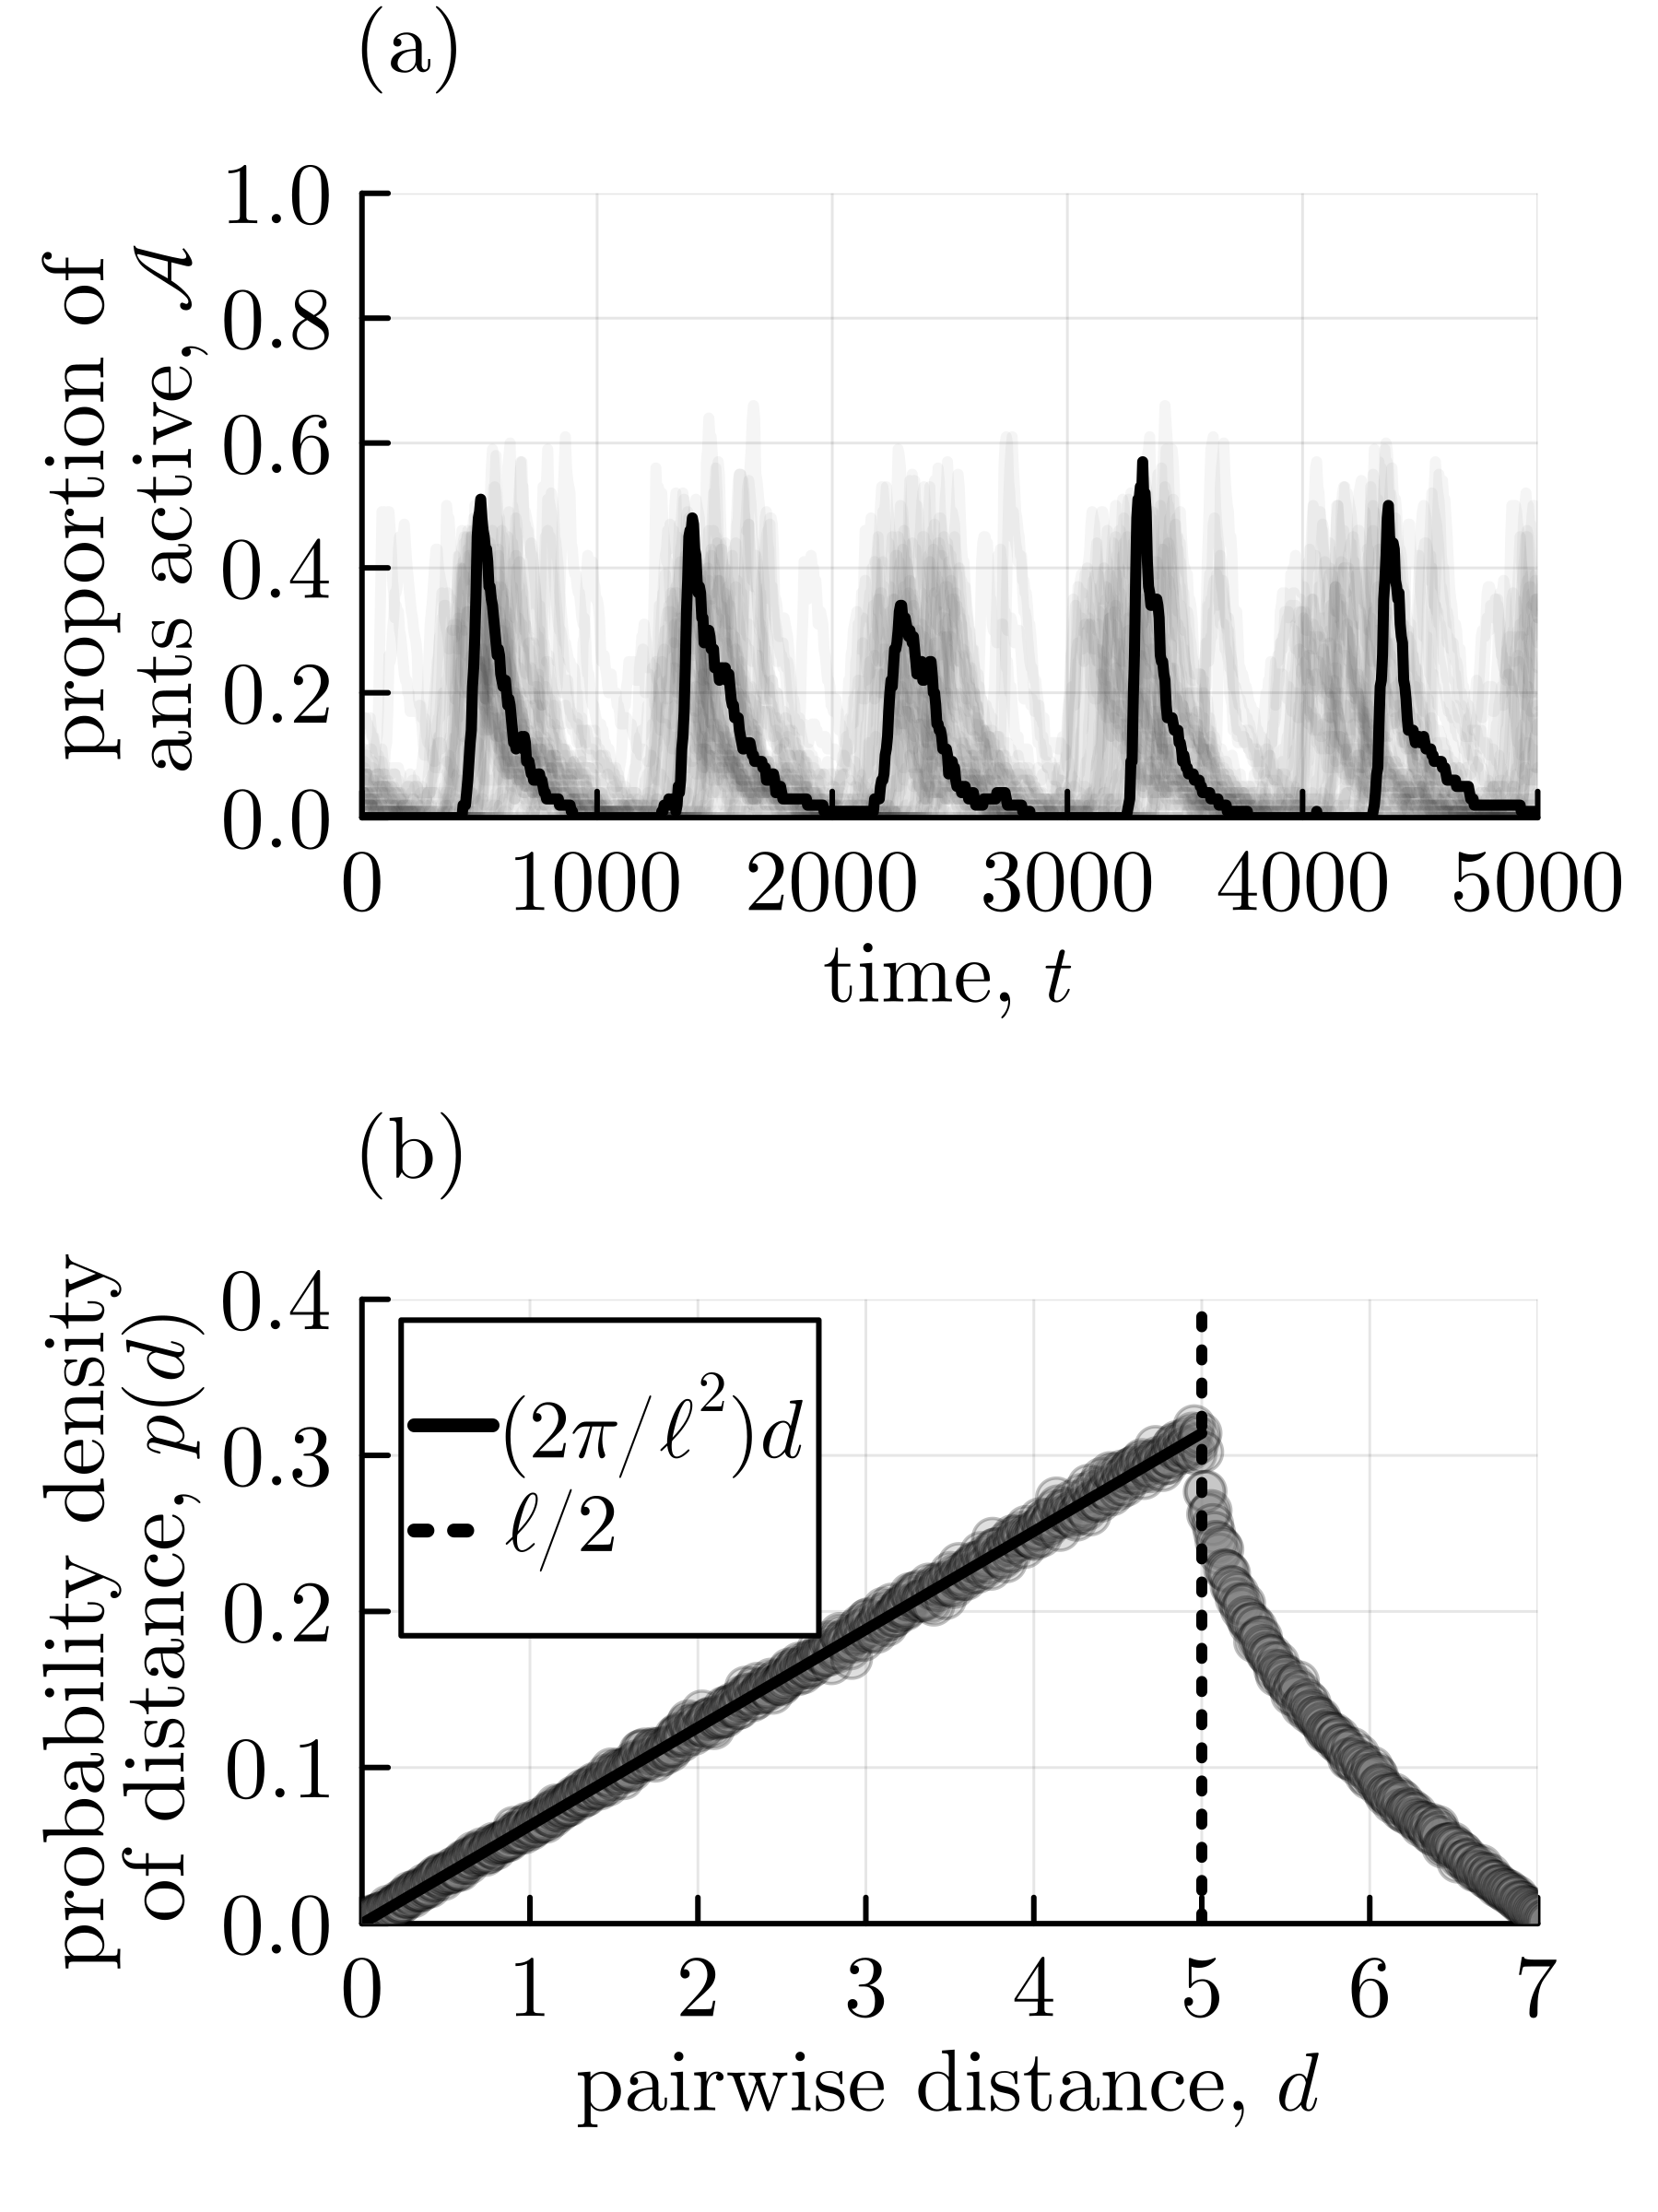

In [7]:
# Plot the distribution of pair-waise distances.
plt = plot( layout=(2,1), size=(300,400), xformatter=:plain, dpi=600 )
plot!( plt; left_margin=0pt, bottom_margin=0pt, right_margin=10pt )

# Plot the activity burst.
m̂ = 10;  M̂ = 50
for m ∈ 1:M̂
    alist = adata[m,:]
    alpha = m == m̂ ? 1 : 1/25
    plot!( plt[1], 10tlist./2, alist; color=:black, alpha=alpha, lw=2, label="" )
end

plot!( plt[1]; xlims=(0,10*500), xlabel="time, "*L"t" )
plot!( plt[1]; ylims=(0,1.0), ylabel="proportion of\nants active, "*L"\mathcal{A}" )

title!( plt[1], "(a)"; title_position=:left )

# Plot the pairwise distance distribution.
ilist = 0.0 .< flist
scatter!( plt[2], d̂list[ilist], flist[ilist]; color=:gray, alpha=1/4, marker=:circ, label="" )
plot!( plt[2], xlist, ylist; color=:black, lw=2, label=L"(2π/ℓ^2) d" )

ystep = 0.1;  ymax = ystep*ceil( maximum( flist )/ystep )
plot!( plt[2], [L/2, L/2], [0, ymax]; color=:black, linestyle=:dot, lw=2, label=L"ℓ/2" )

plot!( plt[2]; xlims=(0,floor( dmax )), ylims=(0,ymax) )
plot!( plt[2]; yticks=0:ystep:ymax )

plot!( plt[2]; xlabel="pairwise distance, "*L"d", ylabel="probability density\nof distance, "*L"p(d)", legend=:topleft )

title!( plt[2], "(b)"; title_position=:left )

saveplot( plt, figurefolder*"activity_pairwise-distance_N-$(N)_mu-$(round( μ, digits=6 )).png" )